In [5]:
import sys
!{sys.executable} -m pip install tqdm

In [6]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

In [17]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
CSV_PATH = "HAM10000_metadata.csv"
IMG_DIR_1 = "HAM10000_images_part_1"
IMG_DIR_2 = "HAM10000_images_part_2"


df = pd.read_csv(CSV_PATH)
df = df[["image_id", "dx"]].copy()

In [8]:
def get_image_path(image_id):
    p1 = os.path.join(IMG_DIR_1, f"{image_id}.jpg")
    p2 = os.path.join(IMG_DIR_2, f"{image_id}.jpg")
    if os.path.exists(p1):
        return p1
    elif os.path.exists(p2):
        return p2
    return None

df["path"] = df["image_id"].apply(get_image_path)
df = df[df["path"].notnull()].reset_index(drop=True)

In [ ]:
def extract_features(img_path, img_size=(64, 64)):
    img = Image.open(img_path).convert("RGB")
    img = img.resize(img_size)
    img_np = np.array(img)

    # color histogram features
    hist_r, _ = np.histogram(img_np[:, :, 0], bins=32, range=(0, 256))
    hist_g, _ = np.histogram(img_np[:, :, 1], bins=32, range=(0, 256))
    hist_b, _ = np.histogram(img_np[:, :, 2], bins=32, range=(0, 256))
    color_hist = np.concatenate([hist_r, hist_g, hist_b]).astype(np.float32)
    color_hist /= (color_hist.sum() + 1e-8)

    # downsampled raw pixel features
    small_img = img.resize((32, 32))
    pixel_features = np.array(small_img).astype(np.float32).flatten() / 255.0

    return np.concatenate([color_hist, pixel_features])

In [10]:
X = []
for path in tqdm(df["path"], desc="Extracting features"):
    X.append(extract_features(path))

X = np.array(X)
y = df["dx"].values

Extracting features: 100%|███████████████| 10015/10015 [01:19<00:00, 126.34it/s]


In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, stratify=y_encoded, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [ ]:
classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight_dict = {i: w for i, w in zip(classes, class_weights)}

## Logistic Regression

In [ ]:
baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight=class_weight_dict,
        multi_class="multinomial",
        solver="lbfgs"
    ))
])

baseline_model.fit(X_train, y_train)

/Users/navyabhardwaj/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [ ]:

y_val_pred = baseline_model.predict(X_val)
print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))

Validation Accuracy: 0.6418109187749668

Validation Classification Report:
              precision    recall  f1-score   support

       akiec       0.29      0.22      0.25        49
         bcc       0.45      0.45      0.45        77
         bkl       0.34      0.48      0.40       165
          df       0.16      0.29      0.20        17
         mel       0.26      0.29      0.27       167
          nv       0.85      0.77      0.81      1006
        vasc       0.42      0.52      0.47        21

    accuracy                           0.64      1502
   macro avg       0.40      0.43      0.41      1502
weighted avg       0.68      0.64      0.66      1502



In [ ]:

y_test_pred = baseline_model.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

Test Accuracy: 0.6294078509647372

Test Classification Report:
              precision    recall  f1-score   support

       akiec       0.28      0.31      0.29        49
         bcc       0.35      0.36      0.35        77
         bkl       0.31      0.40      0.35       165
          df       0.09      0.12      0.10        17
         mel       0.27      0.32      0.29       167
          nv       0.85      0.77      0.80      1006
        vasc       0.38      0.45      0.42        22

    accuracy                           0.63      1503
   macro avg       0.36      0.39      0.37      1503
weighted avg       0.66      0.63      0.64      1503


Confusion Matrix:
[[ 15   9   5   3   8   8   1]
 [ 14  28   9   3   5  11   7]
 [  8  14  66   3  20  53   1]
 [  4   3   2   2   3   2   1]
 [  7   8  34   3  53  61   1]
 [  6  18  94   7 104 772   5]
 [  0   1   3   1   1   6  10]]


The baseline logistic regression model achieved 63% accuracy but struggled with minority classes due to severe class imbalance in HAM10000. In particular, melanoma recall was low, reflecting a high false-negative rate where malignant lesions were misclassified as benign nevi. This highlights the limitations of handcrafted features for complex dermoscopic patterns. In contrast, convolutional neural networks using transfer learning significantly improved both overall performance and melanoma detection.

## Random Forest Classifier

In [18]:
print("Number of usable images:", len(df))
print("\nClass distribution:")
print(df["dx"].value_counts())

Number of usable images: 10015

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [ ]:
print("\nFeature matrix shape:", X.shape)


Feature matrix shape: (10015, 3168)


In [ ]:

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nClasses:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, cls)


Classes:
0 akiec
1 bcc
2 bkl
3 df
4 mel
5 nv
6 vasc


In [ ]:

train_df, temp_df, X_train, X_temp, y_train, y_temp = train_test_split(
    df, X, y_encoded,
    test_size=0.30,
    stratify=y_encoded,
    random_state=42
)

val_df, test_df, X_val, X_test, y_val, y_test = train_test_split(
    temp_df, X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("\nTrain size:", len(X_train))
print("Val size:", len(X_val))
print("Test size:", len(X_test))


Train size: 7010
Val size: 1502
Test size: 1503


In [ ]:

baseline_model = RandomForestClassifier(
    n_estimators=700,
    class_weight="balanced",
    max_depth=40,
    n_jobs=-1,
    random_state=42
)

In [ ]:

print("\nTraining Random Forest...")
baseline_model.fit(X_train, y_train)


Training Random Forest...


,n_estimators,700
,criterion,'gini'
,max_depth,40
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:

y_val_pred = baseline_model.predict(X_val)

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nValidation Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))

print("\nValidation Confusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))


Validation Accuracy: 0.7130492676431425

Validation Classification Report:
              precision    recall  f1-score   support

       akiec       0.67      0.20      0.31        49
         bcc       0.63      0.29      0.39        77
         bkl       0.54      0.24      0.33       165
          df       1.00      0.06      0.11        17
         mel       0.86      0.04      0.07       167
          nv       0.72      0.99      0.83      1006
        vasc       1.00      0.05      0.09        21

    accuracy                           0.71      1502
   macro avg       0.77      0.27      0.31      1502
weighted avg       0.72      0.71      0.64      1502


Validation Confusion Matrix:
[[ 10   3   3   0   0  33   0]
 [  3  22   6   0   0  46   0]
 [  1   7  40   0   0 117   0]
 [  0   1   2   1   0  13   0]
 [  1   0  10   0   6 150   0]
 [  0   1  13   0   1 991   0]
 [  0   1   0   0   0  19   1]]


In [ ]:

y_test_pred = baseline_model.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

print("\nTest Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


Test Accuracy: 0.7005988023952096

Test Classification Report:
              precision    recall  f1-score   support

       akiec       0.50      0.08      0.14        49
         bcc       0.56      0.18      0.27        77
         bkl       0.53      0.28      0.37       165
          df       0.00      0.00      0.00        17
         mel       0.45      0.03      0.06       167
          nv       0.72      0.98      0.83      1006
        vasc       0.00      0.00      0.00        22

    accuracy                           0.70      1503
   macro avg       0.40      0.22      0.24      1503
weighted avg       0.63      0.70      0.62      1503


Test Confusion Matrix:
[[  4   4   5   0   0  36   0]
 [  4  14   6   0   1  52   0]
 [  0   1  47   0   3 114   0]
 [  0   1   4   0   0  12   0]
 [  0   0   9   0   5 153   0]
 [  0   5  16   0   2 983   0]
 [  0   0   1   0   0  21   0]]


/Users/navyabhardwaj/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/navyabhardwaj/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/navyabhardwaj/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

In [36]:
import sys
!{sys.executable} -m pip install seaborn

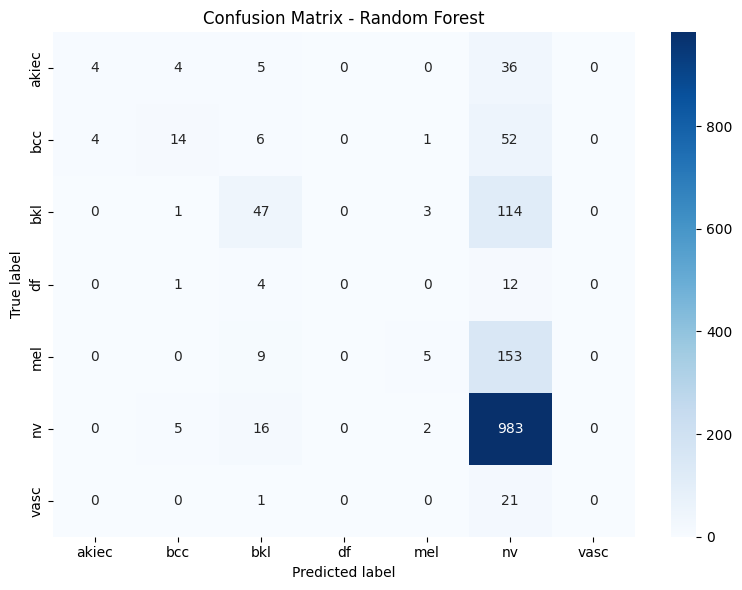

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

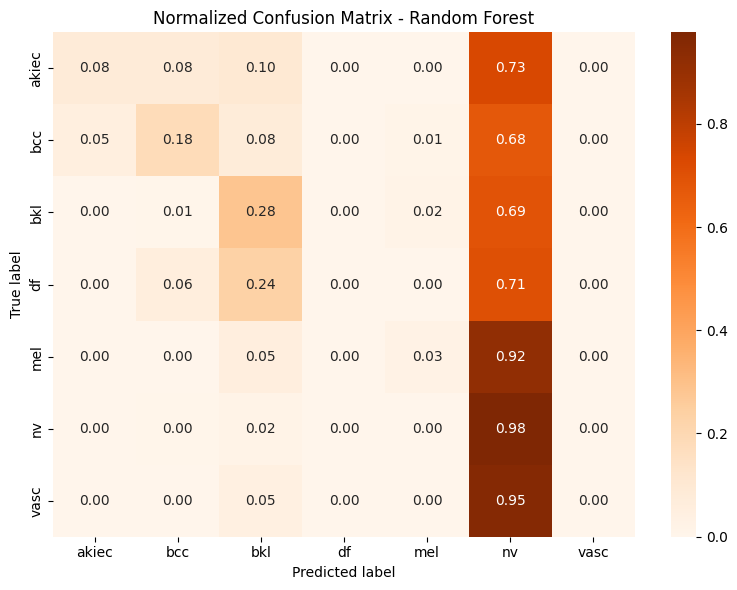

In [38]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Oranges",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

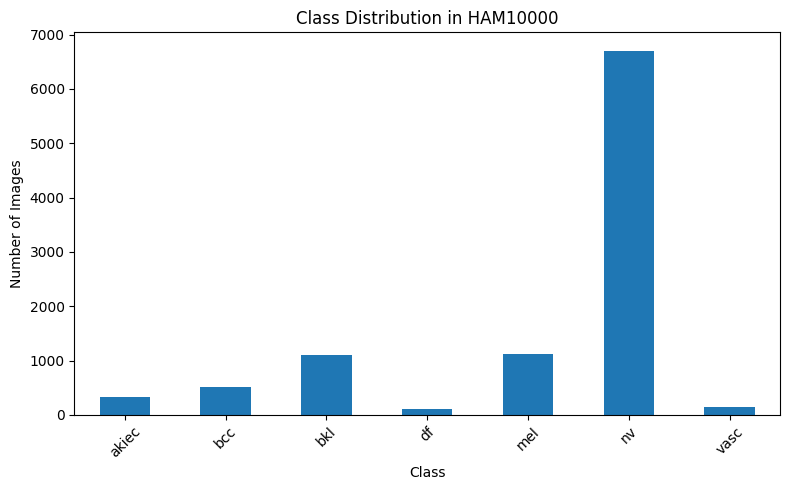

In [39]:
class_counts = df["dx"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("Class Distribution in HAM10000")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/Users/navyabhardwaj/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/navyabhardwaj/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/navyabhardwaj/anaconda3/envs/tf/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

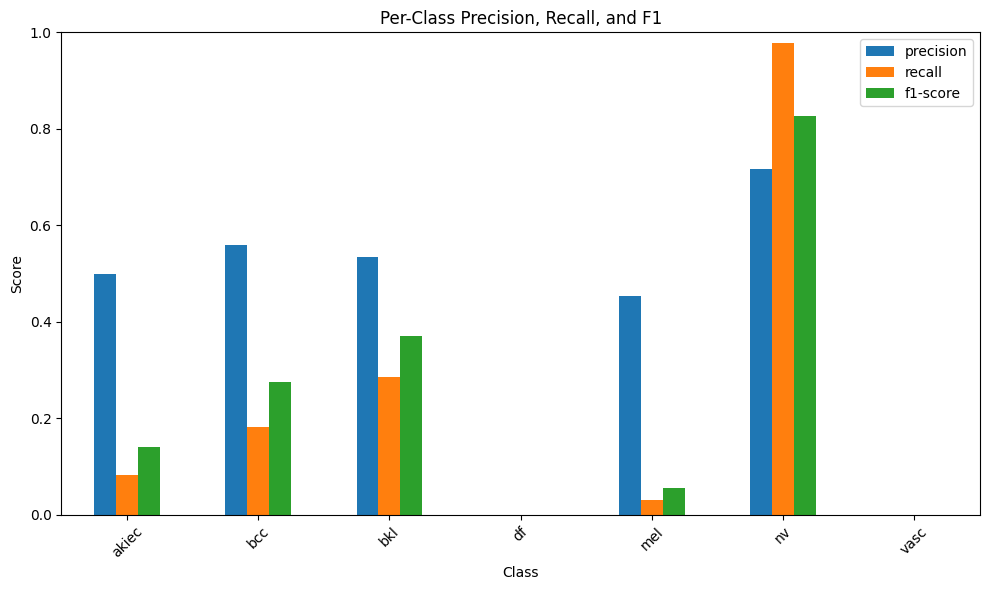

In [40]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_test_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df = report_df.loc[label_encoder.classes_, ["precision", "recall", "f1-score"]]

report_df.plot(kind="bar", figsize=(10, 6))
plt.title("Per-Class Precision, Recall, and F1")
plt.xlabel("Class")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

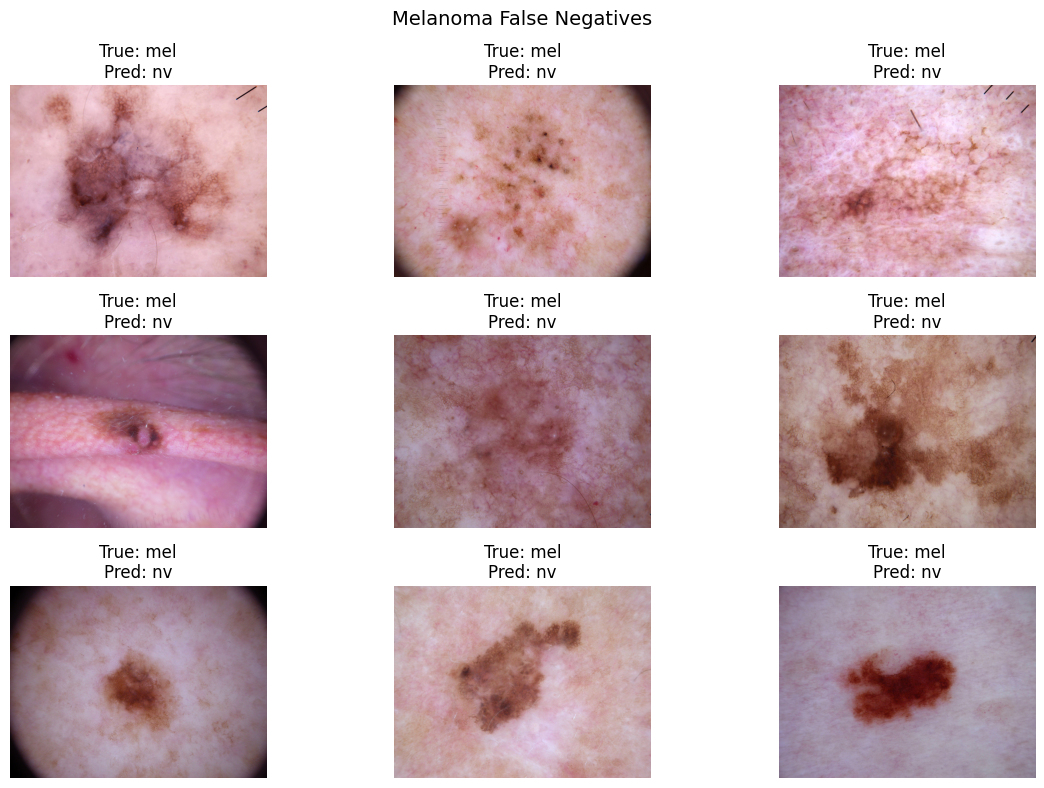

In [43]:
mel_index = label_encoder.transform(["mel"])[0]

fn_indices = np.where((y_test == mel_index) & (y_test_pred != mel_index))[0]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(fn_indices[:9]):
    plt.subplot(3, 3, i + 1)
    
    # find original path from test split
    img = Image.open(test_df.iloc[idx]["path"]).convert("RGB")
    plt.imshow(img)
    
    true_label = label_encoder.inverse_transform([y_test[idx]])[0]
    pred_label = label_encoder.inverse_transform([y_test_pred[idx]])[0]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.suptitle("Melanoma False Negatives", fontsize=14)
plt.tight_layout()
plt.show()

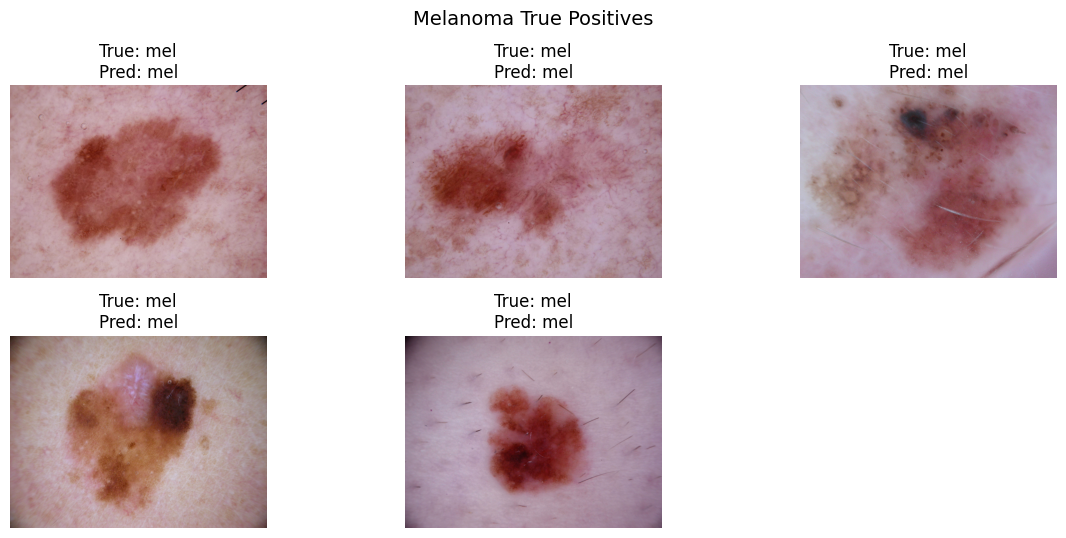

In [44]:
tp_indices = np.where((y_test == mel_index) & (y_test_pred == mel_index))[0]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(tp_indices[:9]):
    plt.subplot(3, 3, i + 1)
    
    img = Image.open(test_df.iloc[idx]["path"]).convert("RGB")
    plt.imshow(img)
    
    true_label = label_encoder.inverse_transform([y_test[idx]])[0]
    pred_label = label_encoder.inverse_transform([y_test_pred[idx]])[0]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.suptitle("Melanoma True Positives", fontsize=14)
plt.tight_layout()
plt.show()

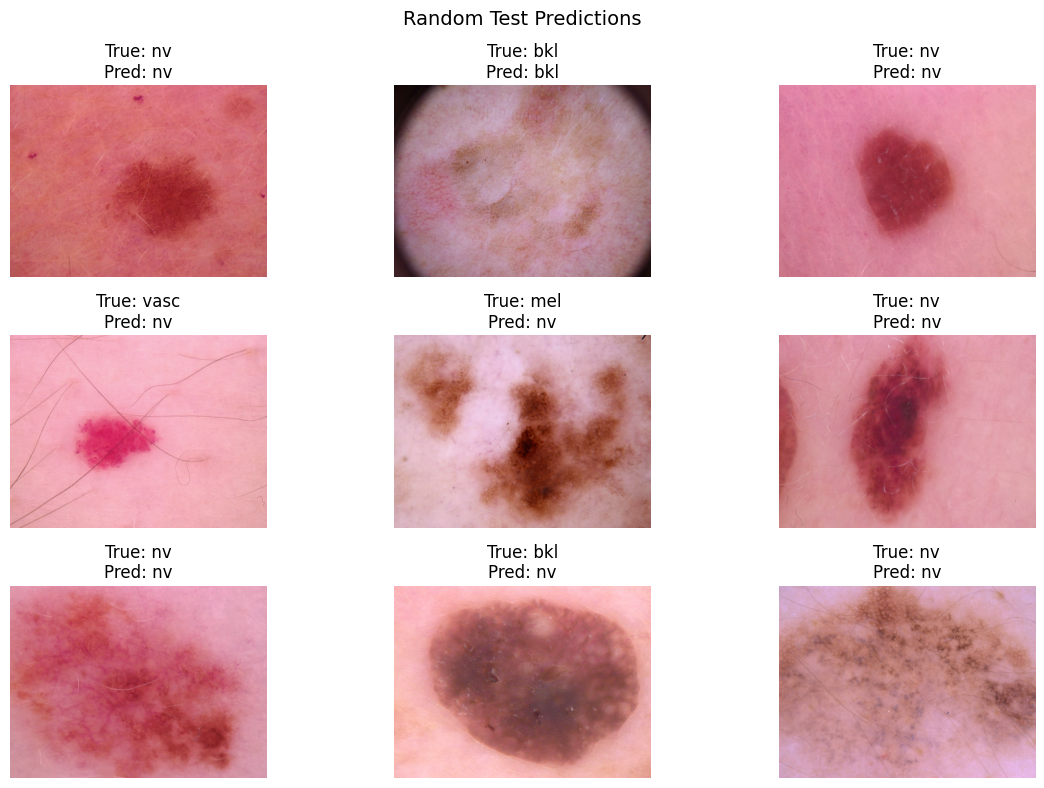

In [45]:
sample_indices = np.random.choice(len(y_test), size=9, replace=False)

plt.figure(figsize=(12, 8))
for i, idx in enumerate(sample_indices):
    plt.subplot(3, 3, i + 1)
    
    img = Image.open(test_df.iloc[idx]["path"]).convert("RGB")
    plt.imshow(img)
    
    true_label = label_encoder.inverse_transform([y_test[idx]])[0]
    pred_label = label_encoder.inverse_transform([y_test_pred[idx]])[0]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.suptitle("Random Test Predictions", fontsize=14)
plt.tight_layout()
plt.show()

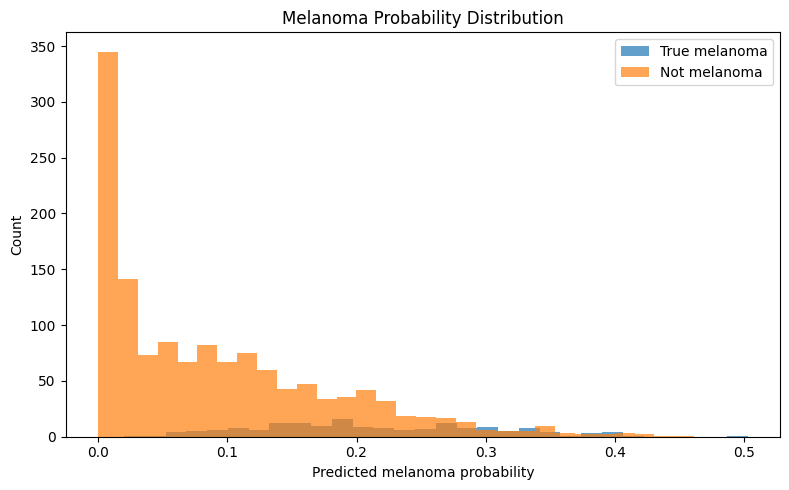

In [46]:
y_test_proba = baseline_model.predict_proba(X_test)

mel_probs = y_test_proba[:, mel_index]

plt.figure(figsize=(8, 5))
plt.hist(mel_probs[y_test == mel_index], bins=30, alpha=0.7, label="True melanoma")
plt.hist(mel_probs[y_test != mel_index], bins=30, alpha=0.7, label="Not melanoma")
plt.xlabel("Predicted melanoma probability")
plt.ylabel("Count")
plt.title("Melanoma Probability Distribution")
plt.legend()
plt.tight_layout()
plt.show()

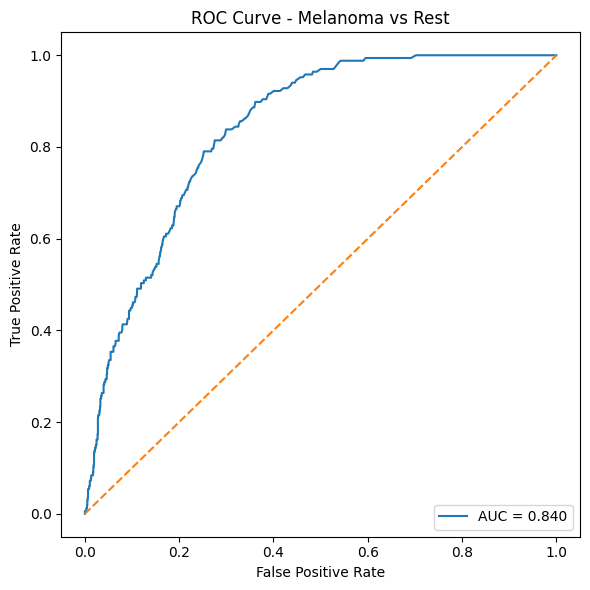

In [47]:
from sklearn.metrics import roc_curve, auc

y_true_mel = (y_test == mel_index).astype(int)
fpr, tpr, _ = roc_curve(y_true_mel, mel_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Melanoma vs Rest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

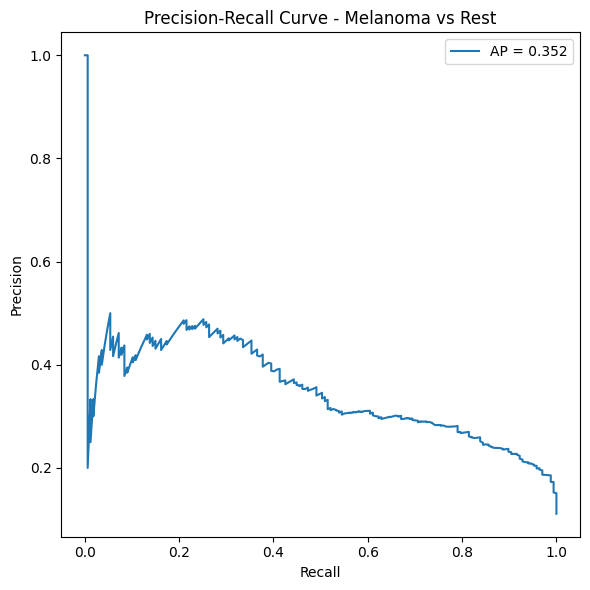

In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_true_mel, mel_probs)
ap = average_precision_score(y_true_mel, mel_probs)

plt.figure(figsize=(6, 6))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Melanoma vs Rest")
plt.legend()
plt.tight_layout()
plt.show()

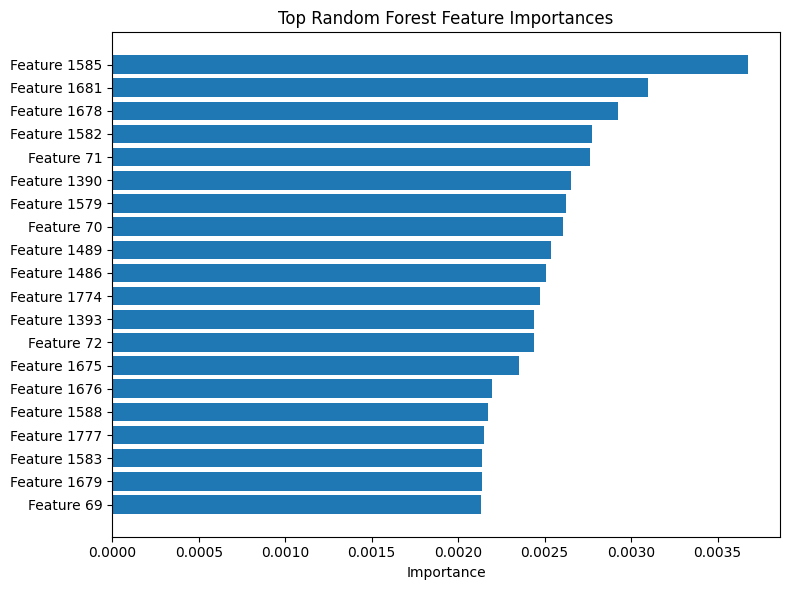

In [49]:
importances = baseline_model.feature_importances_
top_k = 20
top_idx = np.argsort(importances)[-top_k:]

plt.figure(figsize=(8, 6))
plt.barh(range(top_k), importances[top_idx])
plt.yticks(range(top_k), [f"Feature {i}" for i in top_idx])
plt.xlabel("Importance")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [50]:
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

pairs = []
for i in range(cm_no_diag.shape[0]):
    for j in range(cm_no_diag.shape[1]):
        if cm_no_diag[i, j] > 0:
            pairs.append((label_encoder.classes_[i], label_encoder.classes_[j], cm_no_diag[i, j]))

pairs = sorted(pairs, key=lambda x: x[2], reverse=True)

confused_df = pd.DataFrame(pairs[:10], columns=["True Class", "Predicted Class", "Count"])
print(confused_df)

  True Class Predicted Class  Count
0        mel              nv    153
1        bkl              nv    114
2        bcc              nv     52
3      akiec              nv     36
4       vasc              nv     21
5         nv             bkl     16
6         df              nv     12
7        mel             bkl      9
8        bcc             bkl      6
9      akiec             bkl      5
